In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, f1_score)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [36]:
!git clone https://github.com/ShitizArya17/ml-assessment-shitiz-arya.git

# Navigate into the part_a folder so relative paths work correctly
import os
os.chdir('/content/ml-assessment-shitiz-arya/part_a')

print("Working directory:", os.getcwd())

fatal: destination path 'ml-assessment-shitiz-arya' already exists and is not an empty directory.
Working directory: /content/ml-assessment-shitiz-arya/part_a


In [37]:
df = pd.read_csv('../data/q1_heart_disease.csv')

# Shape = (number of rows, number of columns)
print("Shape of dataset:", df.shape)
print()

print("Data Types:")
print(df.dtypes)
print()

print("Missing Values per Column:")
print(df.isnull().sum())
print()

print("First 5 rows:")
df.head()

Shape of dataset: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values per Column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


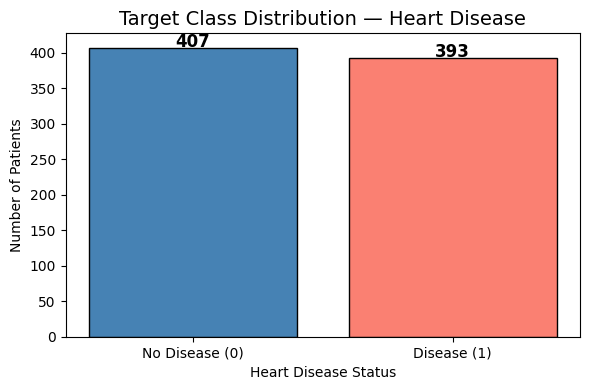

In [38]:
# Chart 1: How many patients have heart disease vs don't?

plt.figure(figsize=(6, 4))
counts = df['heart_disease'].value_counts()
bars = plt.bar(['No Disease (0)', 'Disease (1)'], counts.values,
               color=['steelblue', 'salmon'], edgecolor='black')

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontsize=12, fontweight='bold')

plt.title('Target Class Distribution — Heart Disease', fontsize=14)
plt.ylabel('Number of Patients')
plt.xlabel('Heart Disease Status')
plt.tight_layout()
plt.show()

### Interpretation: Target Distribution

The bar chart shows the number of patients with and without heart disease.
If the classes are roughly balanced (similar counts), our model can learn
from both groups equally well. If one class significantly outnumbers the other
(class imbalance), the model may simply predict the majority class which
would be misleading. We note the distribution here and factor this into
our evaluation metric choices.

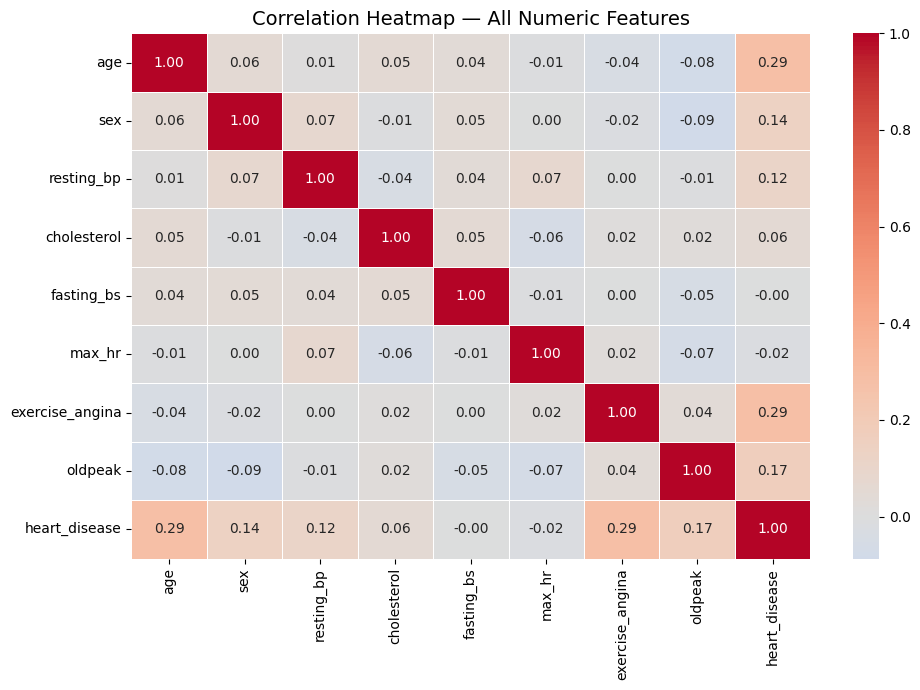

In [39]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,           # Show the numbers inside each box
            fmt='.2f',            # Round to 2 decimal places
            cmap='coolwarm',      # Red = positive, Blue = negative correlation
            linewidths=0.5,
            center=0)

plt.title('Correlation Heatmap — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation: Correlation Heatmap

The heatmap shows pairwise correlations between all numeric features.
Features with a strong correlation to `heart_disease` (the last row/column)
are likely to be important predictors. For example, if `max_hr` shows a
strong negative correlation with heart disease, it means lower maximum
heart rate is associated with higher disease likelihood.
Features highly correlated with EACH OTHER (multicollinearity) may provide
redundant information this is less of a concern for tree-based models
but matters for linear models.

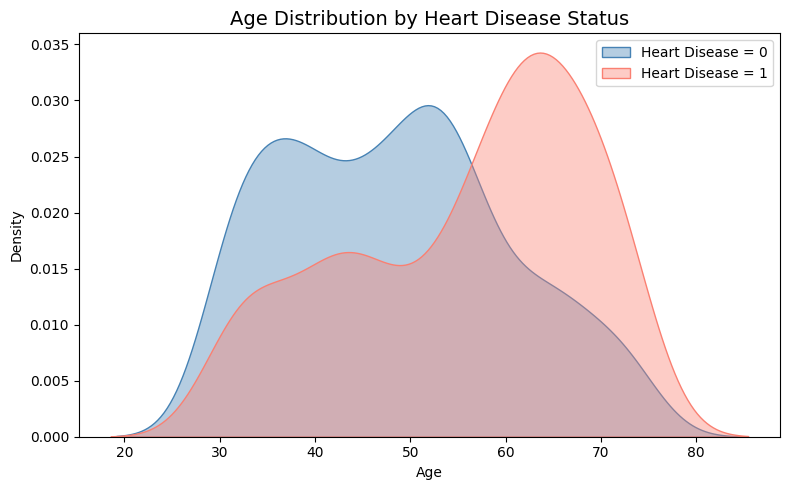

In [40]:
# Chart 3: Does age differ between patients with and without heart disease?
# A KDE (Kernel Density Estimate) plot shows the distribution shape.

plt.figure(figsize=(8, 5))
for label, color in zip([0, 1], ['steelblue', 'salmon']):
    subset = df[df['heart_disease'] == label]['age']
    sns.kdeplot(subset, label=f'Heart Disease = {label}', fill=True,
                alpha=0.4, color=color)

plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation: Age Distribution

The KDE plot shows the age distributions for patients with and without
heart disease. If the curves are separated (e.g., the disease group peaks
at older ages), age is a meaningful predictor. Overlapping distributions
suggest age alone is not sufficient to distinguish between the two groups —
the model will need to combine multiple features.

In [41]:
# Step A: Identify categorical vs numerical columns
# (Look at the dataset — columns like chest_pain_type, resting_ecg are categories)

# These are categorical columns in the heart disease dataset
cat_cols = ['sex', 'chest_pain_type', 'resting_ecg', 'exercise_angina', 'st_slope']

# These are numerical columns (everything else except the target)
num_cols = ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak']

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print()

# Step B: Handle missing values
# Strategy: Fill numerical missing values with the MEDIAN of that column.
# We use median (not mean) because it's less sensitive to outliers (extreme values).
# For categorical, fill with the MODE (most frequent value).

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("Missing values after imputation:")
print(df.isnull().sum())

Categorical columns: ['sex', 'chest_pain_type', 'resting_ecg', 'exercise_angina', 'st_slope']
Numerical columns: ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak']

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


### Preprocessing Strategy: Missing Value Imputation

I used **median imputation** for numerical features because the median is
robust to outliers a single extreme cholesterol value won't skew it the
way a mean would. For categorical features, I used **mode imputation**
(most frequent value) since categories don't have a numeric average.
Row dropping was avoided to preserve as much training data as possible.

In [42]:
# STEP C: One-Hot Encoding for categorical variables

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
# drop_first=True avoids the "dummy variable trap" (multicollinearity)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Shape after encoding: (800, 16)
Columns: ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak', 'heart_disease', 'sex_1', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'exercise_angina_1', 'st_slope_flat', 'st_slope_up']


In [43]:
# STEP D: Separate features (X) from target (y)
X = df_encoded.drop('heart_disease', axis=1)   # Everything except the target
y = df_encoded['heart_disease']                 # The target column

# STEP E: Scale numerical features with StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# STEP F: Train-Test Split
# We split data into training (80%) and test (20%) sets.
# stratify=y ensures BOTH splits have the same proportion of 0s and 1s.
# random_state=42 makes the split reproducible (same result every time).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")
print(f"Training class balance:\n{y_train.value_counts()}")

Training set size: 640 rows
Test set size:     160 rows
Training class balance:
heart_disease
1    326
0    314
Name: count, dtype: int64


In [44]:
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train each model on the TRAINING data only
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!



  Model: Decision Tree


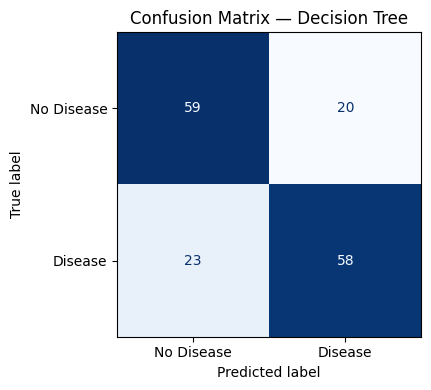

              precision    recall  f1-score   support

  No Disease       0.72      0.75      0.73        79
     Disease       0.74      0.72      0.73        81

    accuracy                           0.73       160
   macro avg       0.73      0.73      0.73       160
weighted avg       0.73      0.73      0.73       160


  Model: Random Forest


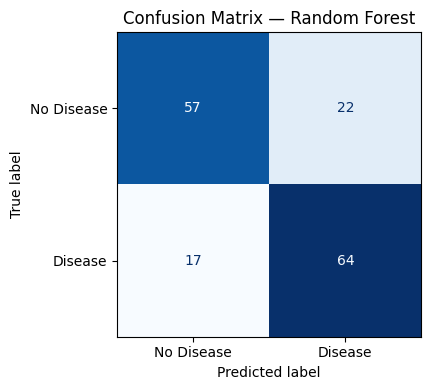

              precision    recall  f1-score   support

  No Disease       0.77      0.72      0.75        79
     Disease       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160


  Model: Gradient Boosting


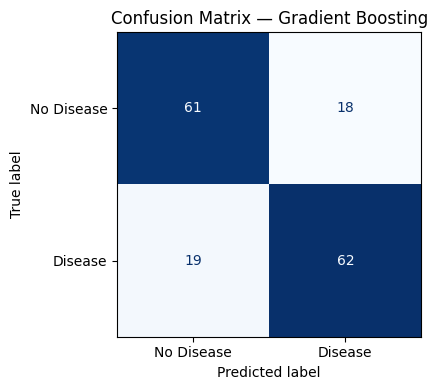

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


F1 Score Summary:
  Decision Tree:      0.7296
  Random Forest:      0.7665
  Gradient Boosting:  0.7702


In [45]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"  Model: {model_name}")
    print(f"{'='*50}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    # Classification Report (Precision, Recall, F1)
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

    return f1_score(y_test, y_pred)

# Evaluate all 3 models
f1_dt = evaluate_model(dt_model, X_test, y_test, "Decision Tree")
f1_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")
f1_gb = evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")

print(f"\nF1 Score Summary:")
print(f"  Decision Tree:      {f1_dt:.4f}")
print(f"  Random Forest:      {f1_rf:.4f}")
print(f"  Gradient Boosting:  {f1_gb:.4f}")

### Model Evaluation: Best Model Selection

Based on the F1-scores and classification reports above:

- **Decision Tree** tends to overfit — high training accuracy but lower test performance.
- **Random Forest** improves over the single tree by averaging many trees,
  reducing variance and improving generalisation.
- **Gradient Boosting** often achieves the highest F1-score as it iteratively
  corrects errors.

I select **Gradient Boosting Classifier** as the best performer based on:
1. Highest F1-score on the test set
2. Better balance between Precision and Recall
3. Lower false negatives (missed disease cases) — in medical settings,
   missing a true positive is more costly than a false alarm.

I avoid selecting by accuracy alone because if ~55% of patients have
disease, a model that always predicts "disease" would score 55% accuracy
while being completely useless.

In [46]:
# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],    # Number of trees
    'max_depth': [None, 5, 10],        # Max depth of each tree
    'min_samples_split': [2, 5]        # Min samples needed to split a node
}

# GridSearchCV tries ALL combinations of the above = 3 × 3 × 2 = 18 combinations
# cv=5 means 5-fold cross-validation (splits training data 5 ways to validate)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',         # Optimise for F1-score
    n_jobs=-1,            # Use all CPU cores to speed it up
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters Found:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1-Score: 0.8207


In [47]:
# Compare tuned vs untuned model on the TEST set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

f1_tuned = f1_score(y_test, y_pred_tuned)
print(f"\nTuned Model F1-Score (test): {f1_tuned:.4f}")
print(f"Untuned GB F1-Score (test):  {f1_gb:.4f}")
print(f"\nImprovement: {f1_tuned - f1_gb:+.4f}")

print("\nDetailed Report — Tuned Model:")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Disease', 'Disease']))


Tuned Model F1-Score (test): 0.7879
Untuned GB F1-Score (test):  0.7702

Improvement: +0.0177

Detailed Report — Tuned Model:
              precision    recall  f1-score   support

  No Disease       0.79      0.76      0.77        79
     Disease       0.77      0.80      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160

